# M-MMLU vs RankMe Correlation

Evaluates multilingual LLMs on **[openai/MMMLU](https://huggingface.co/datasets/openai/MMMLU)**
(the same MMLU questions professionally translated into 14 languages) and correlates
per-language accuracy with the **RankMe** score the model obtains in that language.

**Configuration** lives entirely in `configs/giacomo.yaml`:
- Which models to evaluate and where their RankMe CSVs are
- Which languages and their `openai/MMMLU` subset codes
- Which checkpoint / layer / aggregation to extract RankMe from
- Evaluation hyperparameters (few-shot count, batch size, limit, device)

Evaluation uses standard 5-shot log-prob scoring (no lm-eval dependency needed).
M-MMLU results are **cached** in `results/mmmlu/` so re-running the notebook is cheap.
Set `FORCE_RERUN = True` in the evaluation cell to redo inference.

In [14]:
import gc
import os
import sys
import json
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from tqdm.auto import tqdm
from datasets import load_dataset, get_dataset_config_names
from transformers import AutoModelForCausalLM, AutoTokenizer

# Resolve project root whether the notebook is run from notebooks/ or from root
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"Notebook dir : {NOTEBOOK_DIR}")

Project root : /scratch/giacomo/open-project-m2-jpmg
Notebook dir : /scratch/giacomo/open-project-m2-jpmg/notebooks


In [15]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Override by setting env var GIACOMO_CONFIG=/path/to/other.yaml
CONFIG_PATH = Path(os.environ.get(
    "GIACOMO_CONFIG",
    NOTEBOOK_DIR / "configs" / "giacomo.yaml"
))

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

models_cfg = config["models"]
eval_cfg   = config["evaluation"]
rankme_cfg = config["rankme"]
output_cfg = config.get("output", {})
languages  = eval_cfg["languages"]

results_dir = PROJECT_ROOT / output_cfg.get("results_dir", "results/mmmlu")
figures_dir = PROJECT_ROOT / output_cfg.get("figures_dir", "results/figures")
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Config       : {CONFIG_PATH}")
print(f"Models       : {[m['name'] for m in models_cfg]}")
print(f"Languages    : {[l['name'] for l in languages]}")
print(f"RankMe config: checkpoint={rankme_cfg['checkpoint']!r}, "
      f"layer={rankme_cfg['layer']!r}, agg={rankme_cfg['aggregation']!r}")
print(f"Results dir  : {results_dir}")
print(f"Figures dir  : {figures_dir}")

Config       : /scratch/giacomo/open-project-m2-jpmg/notebooks/configs/giacomo.yaml
Models       : ['Apertus', 'FuxiTranyu-8B']
Languages    : ['French', 'Chinese', 'German', 'Spanish', 'Italian', 'Indonesian', 'Arabic', 'Japanese', 'Hindi', 'Swahili']
RankMe config: checkpoint='main', layer='layer_27', agg='mean'
Results dir  : /scratch/giacomo/open-project-m2-jpmg/results/mmmlu
Figures dir  : /scratch/giacomo/open-project-m2-jpmg/results/figures


## 1. Load RankMe Scores

Each model's RankMe CSV (produced by `geometry_analysis/geometry_analysis.py`) is filtered
to the configured **checkpoint / layer / aggregation** to obtain one score per language.

In [16]:
def _resolve_checkpoint(df: pd.DataFrame, checkpoint: str, model_name: str) -> str:
    """Return the checkpoint string to filter on, handling 'auto' mode."""
    if checkpoint != "auto":
        return checkpoint
    if "main" in df["checkpoint"].values:
        resolved = "main"
    else:
        resolved = df["checkpoint"].iloc[-1]
    print(f"[{model_name}] auto checkpoint -> '{resolved}'")
    return resolved


def load_rankme_scores(
    model_cfg: dict,
    rankme_cfg: dict,
    project_root: Path,
) -> pd.DataFrame:
    """
    Load RankMe scores for one model.
    Returns a DataFrame with columns [language, rankme] for the configured
    checkpoint/layer/aggregation, or an empty DataFrame on failure.
    """
    path = project_root / model_cfg["rankme_path"]
    name = model_cfg["name"]

    if not path.exists():
        print(f"[{name}] RankMe file not found: {path}")
        return pd.DataFrame(columns=["language", "rankme"])

    df = pd.read_csv(path)
    ckpt  = _resolve_checkpoint(df, rankme_cfg["checkpoint"], name)
    layer = rankme_cfg["layer"]
    agg   = rankme_cfg["aggregation"]

    mask = (
        (df["checkpoint"] == ckpt) &
        (df["layer"]      == layer) &
        (df["aggregation"] == agg)
    )
    filtered = df[mask].copy()

    if filtered.empty:
        print(f"[{name}] No rows for checkpoint='{ckpt}', layer='{layer}', agg='{agg}'")
        print(f"  Available checkpoints : {sorted(df['checkpoint'].unique())}")
        print(f"  Available layers      : {sorted(df['layer'].unique())}")
        print(f"  Available aggregations: {sorted(df['aggregation'].unique())}")
        return pd.DataFrame(columns=["language", "rankme"])

    return filtered[["dataset", "rankme"]].rename(columns={"dataset": "language"})


def load_all_rankme(
    model_cfg: dict,
    checkpoint: str,
    project_root: Path,
) -> pd.DataFrame:
    """Load all layers x aggregations for one model at one checkpoint (layer analysis)."""
    path = project_root / model_cfg["rankme_path"]
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    ckpt = _resolve_checkpoint(df, checkpoint, model_cfg["name"])
    return df[df["checkpoint"] == ckpt].copy()


# ── Load primary RankMe scores ─────────────────────────────────────────────────
rankme_dfs: dict[str, pd.DataFrame] = {}
for mcfg in models_cfg:
    df = load_rankme_scores(mcfg, rankme_cfg, PROJECT_ROOT)
    rankme_dfs[mcfg["name"]] = df
    if not df.empty:
        print(f"\n{mcfg['name']} -- RankMe (ckpt={rankme_cfg['checkpoint']}, "
              f"layer={rankme_cfg['layer']}, agg={rankme_cfg['aggregation']}):")
        for _, row in df.iterrows():
            print(f"  {row['language']:<15}: {row['rankme']:.3f}")
    else:
        print(f"\n{mcfg['name']}: no RankMe scores loaded.")

[Apertus] RankMe file not found: /scratch/results/apertus.csv

Apertus: no RankMe scores loaded.

FuxiTranyu-8B -- RankMe (ckpt=main, layer=layer_27, agg=mean):
  English        : 170.948
  French         : 45.602


## 2. M-MMLU Evaluation

Uses **[openai/MMMLU](https://huggingface.co/datasets/openai/MMMLU)** — the original
MMLU questions professionally translated into 14 languages, one HuggingFace subset per language.

Evaluation protocol:
- **5-shot**: 5 examples prepended as context (from the dataset's `dev` split if present,
  otherwise the first 5 rows of `test` are used as context and excluded from scoring)
- **Log-prob scoring**: for each question the model scores tokens ` A` ` B` ` C` ` D`
  at the last position; the highest log-prob wins (no generation needed)
- **Batched**: multiple questions processed together for speed

Results are **cached** as JSON in `results/mmmlu/`. Set `FORCE_RERUN = True` to redo.

In [17]:
# ── Inspect openai/MMMLU dataset structure ─────────────────────────────────────
# Run this cell once to verify column names and available splits before evaluating.
_configs = get_dataset_config_names("openai/MMMLU")
print(f"Available subsets ({len(_configs)}): {_configs}\n")

# Peek at one subset to see column names and a sample row
_sample_ds = load_dataset("openai/MMMLU", _configs[0], trust_remote_code=True)
print(f"Splits: {list(_sample_ds.keys())}")
print(f"Columns: {_sample_ds[list(_sample_ds.keys())[0]].column_names}")
print(f"\nSample row ({_configs[0]}):")
for k, v in list(_sample_ds.values())[0][0].items():
    print(f"  {k!r}: {v!r}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openai/MMMLU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Available subsets (15): ['default', 'AR_XY', 'BN_BD', 'DE_DE', 'ES_LA', 'FR_FR', 'HI_IN', 'ID_ID', 'IT_IT', 'JA_JP', 'KO_KR', 'PT_BR', 'SW_KE', 'YO_NG', 'ZH_CN']

Splits: ['test']
Columns: ['Unnamed: 0', 'Question', 'A', 'B', 'C', 'D', 'Answer', 'Subject']

Sample row (default):
  'Unnamed: 0': 0
  'Question': 'أوجد درجة امتداد الحقل المحدد Q(sqrt(2)، sqrt(3)، sqrt(18)) على Q.'
  'A': '0'
  'B': '4'
  'C': '2'
  'D': '6'
  'Answer': 'B'
  'Subject': 'abstract_algebra'


In [18]:
# ── Verify configured subsets exist in openai/MMMLU ───────────────────────────
# Cross-check the mmmlu_subset values in the YAML against available configs.
_missing = [
    l for l in eval_cfg["languages"]
    if l["mmmlu_subset"] not in _configs
]
if _missing:
    print("WARNING -- these configured subsets are not in openai/MMMLU:")
    for l in _missing:
        print(f"  {l['name']:<15} -> subset={l['mmmlu_subset']!r}")
    print(f"\nAvailable: {_configs}")
    print("Fix: update mmmlu_subset values in configs/giacomo.yaml to match the list above.")
else:
    print(f"All {len(eval_cfg['languages'])} configured subsets found in openai/MMMLU.")

All 10 configured subsets found in openai/MMMLU.


In [19]:
# ── Tokenizer helpers ──────────────────────────────────────────────────────────
def _get_answer_token_ids(tokenizer) -> list:
    """Get token IDs for ' A', ' B', ' C', ' D' (space-prefixed for continuation models)."""
    ids = []
    for letter in "ABCD":
        sp  = tokenizer.encode(f" {letter}", add_special_tokens=False)
        bare = tokenizer.encode(letter,      add_special_tokens=False)
        ids.append(sp[0] if len(sp) == 1 else bare[0] if len(bare) == 1 else sp[-1])
    return ids


# ── Prompt formatting ──────────────────────────────────────────────────────────
def _normalize_row(row) -> dict:
    """Map dataset row to {Question, A, B, C, D, Answer} regardless of column casing."""
    out = {}
    for k, v in (row.items() if hasattr(row, "items") else {}):
        kl = k.lower()
        if kl == "question":
            out["Question"] = str(v)
        elif kl in ("a", "b", "c", "d"):
            out[kl.upper()] = str(v)
        elif kl == "answer":
            out["Answer"] = "ABCD"[v] if isinstance(v, int) else str(v).strip()
    return out


def _fmt_example(row: dict, include_answer: bool) -> str:
    s = (f"{row['Question']}\n"
         f"A. {row['A']}\nB. {row['B']}\nC. {row['C']}\nD. {row['D']}\nAnswer:")
    return s + (f" {row['Answer']}" if include_answer else "")


def _build_prompt(fewshot: list, test_row: dict) -> str:
    return "\n\n".join([_fmt_example(r, True) for r in fewshot] + [_fmt_example(test_row, False)])


# ── Batched log-prob scoring ───────────────────────────────────────────────────
@torch.no_grad()
def _score_batch(model, tokenizer, prompts: list, answer_token_ids: list, device: str) -> list:
    """
    Left-pad the batch so every prompt ends at position -1, then read log-probs
    of the four answer tokens at that position.
    """
    old_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    enc = tokenizer(prompts, return_tensors="pt", truncation=True,
                    max_length=2048, padding=True).to(device)
    logits = model(**enc).logits[:, -1, :]      # (B, vocab)
    scores = logits[:, answer_token_ids]         # (B, 4)
    tokenizer.padding_side = old_side
    return ["ABCD"[i] for i in scores.argmax(dim=-1).tolist()]


# ── Single-language evaluation ─────────────────────────────────────────────────
def evaluate_language_subset(
    model, tokenizer, answer_token_ids: list,
    lang_name: str, subset: str,
    num_fewshot: int, limit, batch_size: int, device: str,
) -> dict:
    ds = load_dataset("openai/MMMLU", subset, trust_remote_code=True)
    split = "test" if "test" in ds else list(ds.keys())[0]
    test_rows = [_normalize_row(ds[split][i]) for i in range(len(ds[split]))]

    if "dev" in ds:
        fewshot = [_normalize_row(ds["dev"][i]) for i in range(min(num_fewshot, len(ds["dev"])))]
    else:
        fewshot   = test_rows[:num_fewshot]
        test_rows = test_rows[num_fewshot:]

    if limit:
        test_rows = test_rows[:int(limit)]

    prompts = [_build_prompt(fewshot, row) for row in test_rows]
    preds   = []
    for i in tqdm(range(0, len(prompts), batch_size), desc=f"{lang_name}", leave=False):
        preds.extend(_score_batch(model, tokenizer, prompts[i:i+batch_size],
                                  answer_token_ids, device))

    correct = sum(p == r["Answer"] for p, r in zip(preds, test_rows))
    return {"accuracy": correct / len(test_rows), "correct": correct,
            "total": len(test_rows), "subset": subset}


# ── Full model evaluation ──────────────────────────────────────────────────────
def run_mmmlu(
    model_cfg: dict,
    eval_cfg: dict,
    results_dir: Path,
    force_rerun: bool = False,
) -> dict:
    """
    Load one model, evaluate all configured languages on openai/MMMLU, cache results.
    Returns {language_name: {accuracy, correct, total, subset}}.
    """
    model_name = model_cfg["name"]
    safe_name  = model_name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")
    cache_path = results_dir / f"mmmlu_{safe_name}.json"

    if cache_path.exists() and not force_rerun:
        print(f"[{model_name}] Loading cached results: {cache_path}")
        return json.load(open(cache_path))

    device   = eval_cfg.get("device", "cuda")
    dtype    = getattr(torch, model_cfg.get("torch_dtype", "bfloat16"))
    hf_id    = model_cfg["hf_id"]
    revision = model_cfg.get("revision", "main")
    trust_rc = model_cfg.get("trust_remote_code", True)

    print(f"[{model_name}] Loading {hf_id} @ {revision} ...")
    tokenizer = AutoTokenizer.from_pretrained(hf_id, revision=revision,
                                              trust_remote_code=trust_rc)
    model = AutoModelForCausalLM.from_pretrained(
        hf_id, revision=revision, torch_dtype=dtype,
        device_map=device, trust_remote_code=trust_rc,
    )
    model.eval()

    answer_token_ids = _get_answer_token_ids(tokenizer)
    print(f"  Answer token IDs: {dict(zip('ABCD', answer_token_ids))}")

    num_fewshot = eval_cfg.get("num_fewshot", 5)
    batch_size  = int(eval_cfg.get("batch_size", 4))
    limit       = eval_cfg.get("limit")
    results     = {}

    for lang in eval_cfg["languages"]:
        lname, subset = lang["name"], lang["mmmlu_subset"]
        print(f"  {lname} ({subset}) ...", flush=True)
        try:
            r = evaluate_language_subset(model, tokenizer, answer_token_ids,
                                         lname, subset, num_fewshot, limit,
                                         batch_size, device)
            results[lname] = r
            print(f"    {r['accuracy']:.4f}  ({r['correct']}/{r['total']})")
        except Exception as e:
            print(f"    ERROR: {e}")
            results[lname] = {"accuracy": None, "error": str(e), "subset": subset}

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    json.dump(results, open(cache_path, "w"), indent=2)
    print(f"[{model_name}] Cached -> {cache_path}")
    return results

In [20]:
FORCE_RERUN = False  # set True to re-run inference even when a cache exists

mmlu_results: dict = {}
for mcfg in models_cfg:
    print(f"\n{'='*55}\nModel: {mcfg['name']}\n{'='*55}")
    mmlu_results[mcfg["name"]] = run_mmmlu(mcfg, eval_cfg, results_dir, FORCE_RERUN)

# Summary table
lang_names = [l["name"] for l in languages]
summary = {"Language": lang_names}
for mcfg in models_cfg:
    mname = mcfg["name"]
    summary[mname] = [
        (mmlu_results.get(mname, {}).get(l) or {}).get("accuracy")
        for l in lang_names
    ]
df_mmlu = pd.DataFrame(summary).set_index("Language")
print("\nM-MMLU Accuracy Summary:")
print(df_mmlu.to_string(float_format="{:.4f}".format))


Model: Apertus
[Apertus] Loading swiss-ai/Apertus-8B-2509 @ main ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  Answer token IDs: {'A': 1349, 'B': 1398, 'C': 1359, 'D': 1407}
  French (FR_FR) ...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openai/MMMLU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


French:   0%|          | 0/25 [00:00<?, ?it/s]

...

Hindi:   0%|          | 0/25 [00:00<?, ?it/s]

    0.2200  (22/100)
  Swahili (SW_KE) ...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openai/MMMLU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Swahili:   0%|          | 0/25 [00:00<?, ?it/s]

    0.2100  (21/100)
[FuxiTranyu-8B] Cached -> /scratch/giacomo/open-project-m2-jpmg/results/mmmlu/mmmlu_fuxitranyu_8b.json

M-MMLU Accuracy Summary:
            Apertus  FuxiTranyu-8B
Language                          
French       0.3600         0.1700
Chinese      0.3100         0.2000
German       0.3100         0.2000
Spanish      0.3700         0.1700
Italian      0.3200         0.2500
Indonesian   0.3800         0.1900
Arabic       0.3200         0.2400
Japanese     0.3200         0.1400
Hindi        0.3800         0.2200
Swahili      0.3100         0.2100


## 3. Correlation Analysis

For each model, we compute the **Pearson** and **Spearman** correlation between:
- RankMe score in language L (from the model's internal representations)
- M-MMLU accuracy in language L (downstream evaluation)

A positive correlation would mean higher-quality representations (high RankMe) -> better downstream performance.

In [21]:
# ── Build merged DataFrame ─────────────────────────────────────────────────────
rows = []
for mcfg in models_cfg:
    mname  = mcfg["name"]
    rm_df  = rankme_dfs.get(mname, pd.DataFrame(columns=["language", "rankme"]))
    rm_map = dict(zip(rm_df["language"], rm_df["rankme"])) if not rm_df.empty else {}

    for lang in languages:
        lname   = lang["name"]
        rm_val  = rm_map.get(lname)
        mmlu_r  = (mmlu_results.get(mname, {}).get(lname) or {})
        acc_val = mmlu_r.get("accuracy")
        rows.append({
            "model":         mname,
            "language":      lname,
            "rankme":        rm_val,
            "mmlu_accuracy": acc_val,
            "has_both":      rm_val is not None and acc_val is not None,
        })

df_merged = pd.DataFrame(rows)

pivot = df_merged.pivot_table(
    values="has_both", index="language", columns="model", aggfunc="first"
)
print("Data completeness (True = both RankMe and MMLU available):")
print(pivot.to_string())

df_valid = df_merged[df_merged["has_both"]].copy()
print(f"\nValid pairs for correlation: {len(df_valid)} / {len(df_merged)}")

Data completeness (True = both RankMe and MMLU available):
model       Apertus  FuxiTranyu-8B
language                          
Arabic        False          False
Chinese       False          False
French        False           True
German        False          False
Hindi         False          False
Indonesian    False          False
Italian       False          False
Japanese      False          False
Spanish       False          False
Swahili       False          False

Valid pairs for correlation: 1 / 20


In [22]:
# ── Compute correlations ───────────────────────────────────────────────────────
corr_results: dict = {}

for mname in df_valid["model"].unique():
    sub = df_valid[df_valid["model"] == mname]
    n   = len(sub)

    if n < 3:
        print(f"{mname}: only {n} data point(s) -- skipping (need >= 3).")
        continue

    pr, pp = stats.pearsonr(sub["rankme"], sub["mmlu_accuracy"])
    sr, sp = stats.spearmanr(sub["rankme"], sub["mmlu_accuracy"])

    corr_results[mname] = {
        "pearson_r":  pr, "pearson_p":  pp,
        "spearman_r": sr, "spearman_p": sp,
        "n": n,
    }
    print(f"{mname}  (n={n}):")
    print(f"  Pearson   r = {pr:+.4f}   p = {pp:.4f}{'  *' if pp < 0.05 else ''}")
    print(f"  Spearman  r = {sr:+.4f}   p = {sp:.4f}{'  *' if sp < 0.05 else ''}")

# Pooled across all models
if len(df_valid) >= 3:
    pr, pp = stats.pearsonr(df_valid["rankme"], df_valid["mmlu_accuracy"])
    sr, sp = stats.spearmanr(df_valid["rankme"], df_valid["mmlu_accuracy"])
    corr_results["Pooled"] = {
        "pearson_r":  pr, "pearson_p":  pp,
        "spearman_r": sr, "spearman_p": sp,
        "n": len(df_valid),
    }
    print(f"\nPooled  (n={len(df_valid)}):")
    print(f"  Pearson   r = {pr:+.4f}   p = {pp:.4f}")
    print(f"  Spearman  r = {sr:+.4f}   p = {sp:.4f}")

FuxiTranyu-8B: only 1 data point(s) -- skipping (need >= 3).


## 4. Visualization

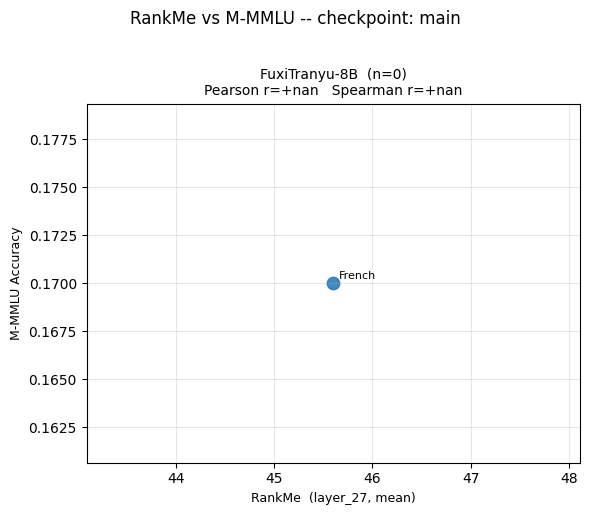

Saved -> /scratch/giacomo/open-project-m2-jpmg/results/figures/rankme_vs_mmmlu_scatter_layer_27_mean.pdf


In [23]:
# ── Scatter: RankMe vs M-MMLU accuracy ────────────────────────────────────────
if df_valid.empty:
    print("No valid data for plotting.")
else:
    model_list  = list(df_valid["model"].unique())
    n_models    = len(model_list)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), squeeze=False)

    for i, mname in enumerate(model_list):
        ax  = axes[0, i]
        sub = df_valid[df_valid["model"] == mname]
        cr  = corr_results.get(mname, {})

        ax.scatter(sub["rankme"], sub["mmlu_accuracy"],
                   s=80, alpha=0.85, color=color_cycle[i])

        for _, row in sub.iterrows():
            ax.annotate(row["language"],
                        (row["rankme"], row["mmlu_accuracy"]),
                        xytext=(4, 3), textcoords="offset points", fontsize=8)

        if len(sub) >= 2:
            m, b = np.polyfit(sub["rankme"], sub["mmlu_accuracy"], 1)
            xs = np.linspace(sub["rankme"].min(), sub["rankme"].max(), 50)
            ax.plot(xs, m * xs + b, "--", color=color_cycle[i], alpha=0.5, linewidth=1.5)

        pr = cr.get("pearson_r",  float("nan"))
        sr = cr.get("spearman_r", float("nan"))
        n  = cr.get("n", 0)
        ax.set_title(f"{mname}  (n={n})\nPearson r={pr:+.3f}   Spearman r={sr:+.3f}",
                     fontsize=10)
        ax.set_xlabel(
            f"RankMe  ({rankme_cfg['layer']}, {rankme_cfg['aggregation']})", fontsize=9
        )
        ax.set_ylabel("M-MMLU Accuracy", fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"RankMe vs M-MMLU -- checkpoint: {rankme_cfg['checkpoint']}",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    fig_path = figures_dir / (
        f"rankme_vs_mmmlu_scatter_{rankme_cfg['layer']}_{rankme_cfg['aggregation']}.pdf"
    )
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fig_path}")

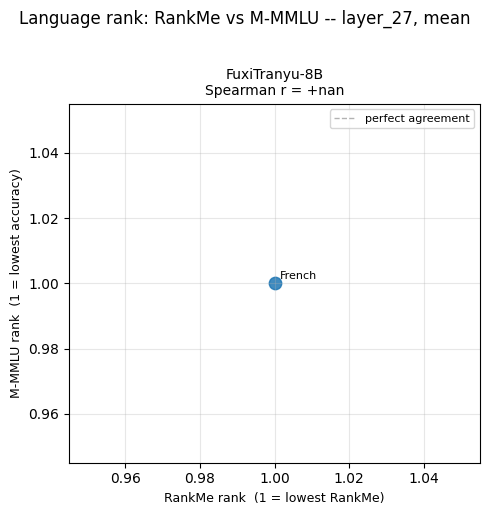

Saved -> /scratch/giacomo/open-project-m2-jpmg/results/figures/rankme_vs_mmmlu_rank_layer_27_mean.pdf


In [24]:
# ── Rank comparison: Spearman rank scatter ─────────────────────────────────────
if not df_valid.empty:
    model_list = list(df_valid["model"].unique())
    n_models   = len(model_list)

    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), squeeze=False)

    for i, mname in enumerate(model_list):
        ax  = axes[0, i]
        sub = df_valid[df_valid["model"] == mname].copy()
        sub["rankme_rank"] = sub["rankme"].rank()
        sub["mmlu_rank"]   = sub["mmlu_accuracy"].rank()

        ax.scatter(sub["rankme_rank"], sub["mmlu_rank"],
                   s=80, alpha=0.85, color=color_cycle[i])

        for _, row in sub.iterrows():
            ax.annotate(row["language"],
                        (row["rankme_rank"], row["mmlu_rank"]),
                        xytext=(4, 3), textcoords="offset points", fontsize=8)

        max_rank = max(sub["rankme_rank"].max(), sub["mmlu_rank"].max())
        ax.plot([1, max_rank], [1, max_rank], "k--", alpha=0.3, linewidth=1,
                label="perfect agreement")

        sr = corr_results.get(mname, {}).get("spearman_r", float("nan"))
        ax.set_title(f"{mname}\nSpearman r = {sr:+.3f}", fontsize=10)
        ax.set_xlabel("RankMe rank  (1 = lowest RankMe)", fontsize=9)
        ax.set_ylabel("M-MMLU rank  (1 = lowest accuracy)", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Language rank: RankMe vs M-MMLU -- {rankme_cfg['layer']}, {rankme_cfg['aggregation']}",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    fig_path = figures_dir / (
        f"rankme_vs_mmmlu_rank_{rankme_cfg['layer']}_{rankme_cfg['aggregation']}.pdf"
    )
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fig_path}")

## 5. Layer-wise Correlation Analysis

How does the Spearman correlation between RankMe and M-MMLU accuracy vary across
**layer depth** and **aggregation method**?

This helps identify which layers' representations are most predictive of downstream
multilingual performance.

In [25]:
# ── Build layer x aggregation correlation table ────────────────────────────────
models_with_mmlu = [
    mcfg["name"] for mcfg in models_cfg
    if any(
        (mmlu_results.get(mcfg["name"]) or {}).get(l["name"], {}).get("accuracy") is not None
        for l in languages
    )
]

layer_corr_rows = []
for mcfg in models_cfg:
    mname = mcfg["name"]
    if mname not in models_with_mmlu:
        print(f"[{mname}] No MMLU results -- skipping layer analysis.")
        continue

    df_all = load_all_rankme(mcfg, rankme_cfg["checkpoint"], PROJECT_ROOT)
    if df_all.empty:
        print(f"[{mname}] No all-layer RankMe data.")
        continue

    mmlu_map = {
        l["name"]: (mmlu_results.get(mname, {}).get(l["name"]) or {}).get("accuracy")
        for l in languages
    }

    for (layer, agg), grp in df_all.groupby(["layer", "aggregation"]):
        pairs = [
            (row["rankme"], mmlu_map.get(row["dataset"]))
            for _, row in grp.iterrows()
            if mmlu_map.get(row["dataset"]) is not None
        ]
        if len(pairs) < 3:
            continue
        rm_vals, mm_vals = zip(*pairs)
        sr, sp = stats.spearmanr(rm_vals, mm_vals)
        pr, pp = stats.pearsonr(rm_vals, mm_vals)
        layer_idx = int(str(layer).replace("layer_", "")) if "layer_" in str(layer) else -1

        layer_corr_rows.append({
            "model": mname, "layer": layer, "layer_idx": layer_idx,
            "aggregation": agg, "spearman_r": sr, "pearson_r": pr, "n": len(pairs),
        })

df_layer = pd.DataFrame(layer_corr_rows)

if df_layer.empty:
    print("No layer-wise data available yet (run M-MMLU evaluation first).")
else:
    print(f"Layer correlation table: {len(df_layer)} rows")
    print(df_layer.sort_values(["model", "aggregation", "layer_idx"]).to_string(index=False))

[Apertus] No all-layer RankMe data.
No layer-wise data available yet (run M-MMLU evaluation first).


In [26]:
# ── Plot: Spearman r vs layer depth, per model x aggregation ──────────────────
if not df_layer.empty:
    models_in_layer = df_layer["model"].unique()
    n_models        = len(models_in_layer)
    agg_styles      = {"mean": "-o", "last": "--s", "first": ":^"}

    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 4), squeeze=False)

    for i, mname in enumerate(models_in_layer):
        ax  = axes[0, i]
        sub = df_layer[df_layer["model"] == mname]

        for agg, grp in sub.groupby("aggregation"):
            grp_s = grp.sort_values("layer_idx")
            ax.plot(grp_s["layer_idx"], grp_s["spearman_r"],
                    agg_styles.get(agg, "-o"), label=agg, markersize=6)

        ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
        cfg_idx = int(rankme_cfg["layer"].replace("layer_", ""))
        ax.axvline(cfg_idx, color="red", linewidth=1, linestyle="--",
                   label=f"config: {rankme_cfg['layer']}")

        ax.set_title(mname, fontsize=11)
        ax.set_xlabel("Layer index", fontsize=9)
        ax.set_ylabel("Spearman r (RankMe vs M-MMLU)", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Spearman r: RankMe vs M-MMLU by layer  (ckpt: {rankme_cfg['checkpoint']})",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    fig_path = figures_dir / "rankme_vs_mmmlu_by_layer.pdf"
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fig_path}")

In [27]:
# ── Heatmap: Spearman r by layer x aggregation (one per model) ─────────────────
if not df_layer.empty:
    for mname in df_layer["model"].unique():
        sub   = df_layer[df_layer["model"] == mname]
        pivot = sub.pivot_table(
            values="spearman_r", index="layer_idx", columns="aggregation"
        ).sort_index()

        fig, ax = plt.subplots(figsize=(4, max(4, len(pivot) * 0.4)))
        sns.heatmap(
            pivot, ax=ax, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Spearman r"}
        )
        ax.set_title(f"{mname} -- Spearman r (RankMe vs M-MMLU)", fontsize=11)
        ax.set_xlabel("Aggregation")
        ax.set_ylabel("Layer index")
        plt.tight_layout()
        safe = mname.lower().replace(" ", "_").replace("/", "_")
        fig_path = figures_dir / f"layer_heatmap_{safe}.pdf"
        plt.savefig(fig_path, bbox_inches="tight")
        plt.show()
        print(f"Saved -> {fig_path}")

## 6. Save Results

In [ ]:
# ── Correlation summary JSON ───────────────────────────────────────────────────
summary_path = results_dir / "correlation_summary.json"
summary = {
    "rankme_config": {
        "checkpoint":  rankme_cfg["checkpoint"],
        "layer":       rankme_cfg["layer"],
        "aggregation": rankme_cfg["aggregation"],
    },
    "correlations": corr_results,
}
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Correlation summary -> {summary_path}")

if not df_layer.empty:
    layer_path = results_dir / "layer_correlation.csv"
    df_layer.drop(columns=["layer_idx"]).to_csv(layer_path, index=False)
    print(f"Layer correlation  -> {layer_path}")

print("\n" + "="*55)
print("SUMMARY")
print("="*55)
print(f"  Checkpoint : {rankme_cfg['checkpoint']}")
print(f"  Layer      : {rankme_cfg['layer']}")
print(f"  Aggregation: {rankme_cfg['aggregation']}")
print()
print(f"{'Model':<20}  {'N':>3}  {'Pearson r':>10}  {'Spearman r':>10}")
print("-" * 50)
for mname, cr in corr_results.items():
    if mname == "Pooled":
        continue
    print(f"{mname:<20}  {cr['n']:>3}  "
          f"{cr['pearson_r']:>+10.4f}  {cr['spearman_r']:>+10.4f}")
if "Pooled" in corr_results:
    cr = corr_results["Pooled"]
    print("-" * 50)
    print(f"{'Pooled':<20}  {cr['n']:>3}  "
          f"{cr['pearson_r']:>+10.4f}  {cr['spearman_r']:>+10.4f}")